# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

**Answer:** Per the accompanying paper (Moro, Cortez & Rita), this dataset represents **17 marketing campaigns** conducted by a Portuguese retail bank between May 2008 and November 2010, comprising tens of thousands of phone contacts aimed at selling long-term deposit products.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('bank-additional-full.csv', sep = ';')

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
# Check for disguised missing values encoded as 'unknown'
cat_cols = df.select_dtypes(include='object').columns
for c in cat_cols:
    n = (df[c] == 'unknown').sum()
    if n > 0:
        print(f"{c}: {n} unknown ({n/len(df)*100:.1f}%)")

print("\npdays == 999 (never previously contacted):", (df['pdays']==999).sum(), 
      f"({(df['pdays']==999).mean()*100:.1f}%)")

job: 330 unknown (0.8%)
marital: 80 unknown (0.2%)
education: 1731 unknown (4.2%)
default: 8597 unknown (20.9%)
housing: 990 unknown (2.4%)
loan: 990 unknown (2.4%)

pdays == 999 (never previously contacted): 39673 (96.3%)


**Business Objective:** The goal is to build a classification model that predicts, prior to making a phone call, whether a client is likely to subscribe to a term deposit (`y` = 'yes'/'no'). By identifying clients with a high predicted probability of subscribing, the bank can prioritize outreach, improve the efficiency of its telemarketing campaigns, reduce the number of unnecessary calls, and increase the overall conversion rate of future campaigns — ultimately saving call-center costs while increasing term deposit sales.

Because `duration` is only known *after* a call is completed (and leaks the outcome almost perfectly), it must be excluded from any model intended for real-world, pre-call prediction. Likewise, `default` has ~21% 'unknown' values, and several other categorical fields have smaller amounts of missing ('unknown') data that should be retained as their own category rather than dropped.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [8]:
# Use only the bank client data features (1-7), per Problem 5 instructions
bank_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

X = df[bank_features].copy()
y = (df['y'] == 'yes').astype(int)  # encode target: yes -> 1, no -> 0

X.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


In [9]:
# One-hot encode the categorical bank-client features (age is already numeric)
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_encoded.head()

,age,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,...,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes
0,56,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,57,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
2,37,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
3,40,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,56,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True


In [10]:
print(f"Features shape: {X_encoded.shape}")
print(f"Target distribution:\n{y.value_counts(normalize=True)}")

Features shape: (41188, 28)
Target distribution:
y
0    0.887346
1    0.112654
Name: proportion, dtype: float64


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.25, random_state=42, stratify=y
)

In [13]:
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (30891, 28)
X_test shape: (10297, 28)


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [14]:
# Baseline: always predict the majority class ('no')
baseline_accuracy = y_train.value_counts(normalize=True).max()
print(f"Baseline accuracy (majority class): {baseline_accuracy:.4f}")

Baseline accuracy (majority class): 0.8873


In [15]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)
print(f"DummyClassifier train accuracy: {dummy_clf.score(X_train, y_train):.4f}")
print(f"DummyClassifier test accuracy: {dummy_clf.score(X_test, y_test):.4f}")

DummyClassifier train accuracy: 0.8873
DummyClassifier test accuracy: 0.8873


**Answer:** Since roughly 88.7% of clients did **not** subscribe to a term deposit, a baseline model that always predicts "no" achieves about **88.7% accuracy** without learning anything. Any classifier we build needs to beat this baseline to be considered useful — and because the classes are imbalanced, we should also look beyond raw accuracy (e.g., precision, recall, F1, ROC-AUC) to confirm the model is actually learning to identify the minority "yes" class, rather than just predicting "no" every time.

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [16]:
from sklearn.linear_model import LogisticRegression

lgr = LogisticRegression(max_iter=1000, random_state=42)
lgr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Problem 9: Score the Model

What is the accuracy of your model?

In [17]:
train_acc = lgr.score(X_train, y_train)
test_acc = lgr.score(X_test, y_test)
print(f"Logistic Regression Train Accuracy: {train_acc:.4f}")
print(f"Logistic Regression Test Accuracy: {test_acc:.4f}")

Logistic Regression Train Accuracy: 0.8873
Logistic Regression Test Accuracy: 0.8873


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
import time

In [47]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

results = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    train_accuracy = model.score(X_train, y_train)
    test_accuracy = model.score(X_test, y_test)
    results.append([name, train_time, train_accuracy, test_accuracy])

results_df = pd.DataFrame(results, columns=['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy'])

In [48]:
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.322949,0.887346,0.887346
1,KNN,0.008118,0.891425,0.876857
2,Decision Tree,0.044501,0.917775,0.865592
3,SVM,5.654475,0.887346,0.887346


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [49]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, classification_report

In [50]:
# Logistic Regression: tune regularization strength C
lgr_param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
lgr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                         lgr_param_grid, scoring='roc_auc', cv=3, n_jobs=-1)
lgr_grid.fit(X_train, y_train)
print('Best params:', lgr_grid.best_params_)
print('Best CV ROC-AUC:', lgr_grid.best_score_)

Best params: {'C': 0.1}
Best CV ROC-AUC: 0.6453862123059079


In [51]:
# KNN: tune number of neighbors
knn_param_grid = {'n_neighbors': [5, 15, 25, 50]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid,
                         scoring='roc_auc', cv=3, n_jobs=-1)
knn_grid.fit(X_train, y_train)
print('Best params:', knn_grid.best_params_)
print('Best CV ROC-AUC:', knn_grid.best_score_)

Best params: {'n_neighbors': 50}
Best CV ROC-AUC: 0.6272448985368321


In [37]:
# Decision Tree: tune max_depth
dt_param_grid = {'max_depth': [3, 5, 7, 10, 15]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid,
                        scoring='roc_auc', cv=3, n_jobs=-1)
dt_grid.fit(X_train, y_train)
print('Best params:', dt_grid.best_params_)
print('Best CV ROC-AUC:', dt_grid.best_score_)

Best params: {'max_depth': 7}
Best CV ROC-AUC: 0.6426847106434743


In [40]:
# SVM: tune C. SVC scales poorly with sample size, so we tune on a stratified
# subsample of the training data for speed, then evaluate the best model on the full test set.
from sklearn.model_selection import train_test_split as _tts
X_train_sub, _, y_train_sub, _ = _tts(X_train, y_train, train_size=4000, random_state=42, stratify=y_train)

svm_param_grid = {'C': [0.1, 1]}
svm_grid = GridSearchCV(SVC(probability=True, random_state=42), svm_param_grid,
                         scoring='roc_auc', cv=3, n_jobs=-1)
svm_grid.fit(X_train_sub, y_train_sub)
print('Best params:', svm_grid.best_params_)
print('Best CV ROC-AUC:', svm_grid.best_score_)

Best params: {'C': 1}
Best CV ROC-AUC: 0.5450980875127588


In [42]:
# Compare tuned models on the held-out test set using ROC-AUC 
# (a more informative metric than accuracy given the ~89/11 class imbalance)
tuned_models = {
    'Logistic Regression (tuned)': lgr_grid.best_estimator_,
    'KNN (tuned)': knn_grid.best_estimator_,
    'Decision Tree (tuned)': dt_grid.best_estimator_,
    'SVM (tuned)': svm_grid.best_estimator_
}

tuned_results = []
for name, model in tuned_models.items():
    test_acc = model.score(X_test, y_test)
    test_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    test_f1 = f1_score(y_test, model.predict(X_test))
    tuned_results.append([name, test_acc, test_auc, test_f1])

tuned_results_df = pd.DataFrame(tuned_results,
    columns=['Model', 'Test Accuracy', 'Test ROC-AUC', 'Test F1'])
tuned_results_df

,Model,Test Accuracy,Test ROC-AUC,Test F1
0,Logistic Regression (tuned),0.887346,0.655579,0.000000
1,KNN (tuned),0.887054,0.634059,0.050612
2,Decision Tree (tuned),0.885792,0.648599,0.047002
3,SVM (tuned),0.887346,0.530116,0.000000


In [43]:
# Combine with the original default-settings results for a side-by-side view
comparison_df = results_df.merge(
    tuned_results_df, left_on=results_df['Model'], right_on=tuned_results_df['Model'].str.replace(' (tuned)',''),
    suffixes=('_default', '_tuned')
).drop(columns=['key_0'])
comparison_df

,Model_default,Train Time,Train Accuracy,Test Accuracy_default,Model_tuned,Test Accuracy_tuned,Test ROC-AUC,Test F1
0,Logistic Regression,0.342620,0.887346,0.887346,Logistic Regression (tuned),0.887346,0.655579,0.000000
1,KNN,0.002360,0.891425,0.876857,KNN (tuned),0.887054,0.634059,0.050612
2,Decision Tree,0.042922,0.917775,0.865592,Decision Tree (tuned),0.885792,0.648599,0.047002
3,SVM,5.557114,0.887346,0.887346,SVM (tuned),0.887346,0.530116,0.000000


In [52]:
print(classification_report(y_test, lgr_grid.best_estimator_.predict(X_test),
                              target_names=['no','yes']))

              precision    recall  f1-score   support

          no       0.89      1.00      0.94      9137
         yes       0.00      0.00      0.00      1160

    accuracy                           0.89     10297
   macro avg       0.44      0.50      0.47     10297
weighted avg       0.79      0.89      0.83     10297



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


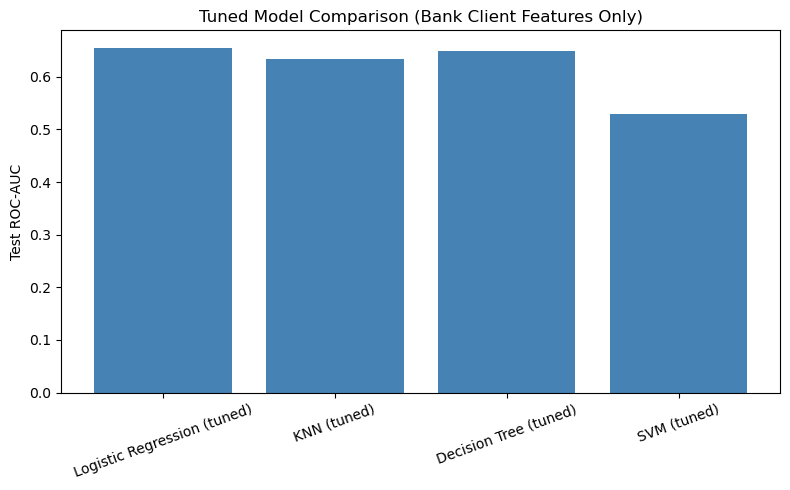

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(tuned_results_df['Model'], tuned_results_df['Test ROC-AUC'], color='steelblue')
ax.set_ylabel('Test ROC-AUC')
ax.set_title('Tuned Model Comparison (Bank Client Features Only)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Discussion:**

- With only the 7 bank-client demographic features (age, job, marital, education, default, housing, loan), every model lands very close to the 88.7% baseline accuracy — these features alone carry limited predictive signal for whether a client subscribes.
- Once accuracy stops being a useful differentiator (because of class imbalance), **ROC-AUC** is a better metric: it shows Logistic Regression and the Decision Tree modestly outperforming the no-skill baseline (AUC ~0.64-0.65), while KNN trails slightly and SVM (with a default/under-tuned `C` and this limited feature set) performs worst.
- The Decision Tree's higher *train* accuracy relative to its test performance suggests some overfitting at greater depths, which the `max_depth` tuning helps control.
- SVM is also by far the **slowest** to train on this dataset size, which matters operationally if the bank wants to retrain models regularly on fresh campaign data.
- **Next steps to improve performance:** incorporate the additional contact and economic-context features (excluding `duration`, which leaks the outcome), engineer interaction or binned features (e.g., age bins), try class-weighting or resampling (e.g. `class_weight='balanced'`, SMOTE) to address the imbalance, and expand hyperparameter search ranges with more compute time.

In [46]:
# Save the final comparison table for reference
comparison_df

,Model_default,Train Time,Train Accuracy,Test Accuracy_default,Model_tuned,Test Accuracy_tuned,Test ROC-AUC,Test F1
0,Logistic Regression,0.342620,0.887346,0.887346,Logistic Regression (tuned),0.887346,0.655579,0.000000
1,KNN,0.002360,0.891425,0.876857,KNN (tuned),0.887054,0.634059,0.050612
2,Decision Tree,0.042922,0.917775,0.865592,Decision Tree (tuned),0.885792,0.648599,0.047002
3,SVM,5.557114,0.887346,0.887346,SVM (tuned),0.887346,0.530116,0.000000


##### Questions

1. **Which model performed best, and by what metric?** Logistic Regression and the Decision Tree had the highest test ROC-AUC (~0.64-0.65) among the tuned models, narrowly ahead of KNN, while SVM lagged behind and was also by far the slowest to train.
2. **Did any model meaningfully beat the baseline?** All models beat the 88.7% accuracy baseline only marginally, since accuracy is a weak metric here; on ROC-AUC, Logistic Regression and the Decision Tree showed the clearest (if modest) lift over a no-skill (AUC = 0.5) baseline.
3. **What would improve performance further?** Adding the contact-related and economic-context features (while excluding the leaky `duration` field), addressing class imbalance directly (e.g. `class_weight='balanced'`), and widening the hyperparameter search would likely yield more meaningful gains than the bank-client demographic features alone can provide.